# 3 Лабораторная <br>
вариант 10

In [61]:
import numpy as np
import math
import matplotlib.pyplot as plt

## Задание 1

По таблице с неравноотстоящими значениями аргумента выполнить интерполяцию. используя формулу Лагранжа.

$x=0.153$ <br>
Точность $e\le0.000001$
|$K$|$X_k$|$Y_k$|
|--|--|--|
|0|0.10|1.66448|
|1|0.20|1.66071|
|2|0.29|1.65734|
|3|0.40|1.65322|
|4|0.49|1.64987| 
|5|0.55|1.64764|


### Объяснение

**Интерполяционный многочлен Лагранжа** используют в таблицах с
неравноотстоящими значениями аргумента. <br>
Формула:
$$
L_n(x)=\sum_{i=0}^n\frac{(x-x_0)(x-x_1)...(x-x_{i-1})(x-x_{i+1})...(x-x_n)}{(x_i-x_0)(x_i-x_1)...(x_i-x_{i-1})(x_i-x_{i+1})...(x_i-x_n)}y_i
$$

Перед вычислениями формулу удобно преобразовать, чтобы вычисления
вести в следующей таблице.

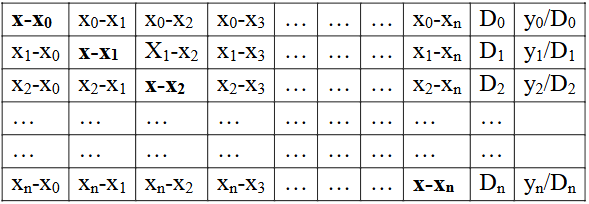

Преобразованная формула принимает вид:
$$
L_n(x)=П_{n+1}(x)\sum_{i=0}^n \frac{y_i}{D_y}
$$
Где: <br>
$П_{n+1}(x)$
-произведение элементов главной диагонали таблицы <br>

$D_i$-произведение элементов i-ой строки таблицы, включая
диагональный элемент. <br>

Погрешность интерполяции можно оценить по формуле:
$$
|R_n(x)| \le \frac{(П_{n+1}(x)|\max|f^{n+1}(x)|)}{(n+1)!}
$$

### Код

In [62]:
def lagrange_tablica(X, Xk, Yk):
    dlin = len(Xk)
    Table = [[0.0 for _ in range(dlin)] for _ in range(dlin)]

    # Заполнение таблицы
    for i in range(dlin):
        for j in range(dlin):
            if i == j:
                Table[i][j] = X - Xk[i]
            else:
                Table[i][j] = Xk[i] - Xk[j]

    # Вычисление Di (произведение элементов строки, кроме диагонали)
    Di = [1.0] * dlin
    for i in range(dlin):
        for j in range(dlin):
            if i != j:
                Di[i] *= Table[i][j]

    # Произведение элементов главной диагонали (числитель)
    D0 = 1.0
    for i in range(dlin):
        D0 *= (X - Xk[i])

    # вычисление интерполяционного полинома
    result = 0.0
    for i in range(dlin):
        Li = 1.0
        for j in range(dlin):
            if j != i:
                Li *= (X - Xk[j]) / (Xk[i] - Xk[j])
        result += Li * Yk[i]
    # вычисление интерполяционного полинома

    return Table, Di, D0, result


def lagrange_interpolation(x_val, Xk, Yk):
    n = len(Xk)
    result = 0.0

    for i in range(n):
        # L_i(x)
        term = Yk[i]
        for j in range(n):
            if j != i:
                term *= (x_val - Xk[j]) / (Xk[i] - Xk[j])
        result += term
        # L_i(x)
    return result

In [63]:

def print_lagrange(Table, Di, D0, Yk, result, x):
    dlin = len(Table)
    sum_y_di = 0.0
    print("\nТаблица:")
    for i in range(dlin):
        val = Yk[i] / Di[i]
        sum_y_di += val
        for j in range(dlin):
            print(f"{Table[i][j]:.6f}|", end=" ")
            if j == dlin - 1:
                print(f"D{i} = {Di[i]:.10f} | Y{i}/D{i} = {val:.10f}")
    print(f"\nПроизведение главной диагонали (D0) = {D0:.6e}")
    print(f"\nY(x={x}) = {result:.10f}")

def plot(xlot, ylot):
    plt.figure(figsize=(10, 6))

    plt.plot(xlot, ylot, 'b-', linewidth=2)

    plt.plot(Xk, Yk, 'ro', markersize=8)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True, alpha=0.3)
    plt.show()

### Решение задачи из практики:

In [64]:
x=0.527
Xk = [0.43, 0.48, 0.55,
      0.62, 0.70, 0.75]
Yk = [1.63597, 1.73234, 1.87686, 2.03345, 2.22846, 2.83973]

Table, Di, D0, result = lagrange_tablica(x, Xk, Yk)
print_lagrange(Table, Di, D0, Yk, result, x)


Таблица:
0.097000| -0.050000| -0.120000| -0.190000| -0.270000| -0.320000| D0 = -0.0000984960 | Y0/D0 = -16609.5069850552
0.050000| 0.047000| -0.070000| -0.140000| -0.220000| -0.270000| D1 = 0.0000291060 | Y1/D1 = 59518.3123754552
0.120000| 0.070000| -0.023000| -0.070000| -0.150000| -0.200000| D2 = -0.0000176400 | Y2/D2 = -106397.9591836735
0.190000| 0.140000| 0.070000| -0.093000| -0.080000| -0.130000| D3 = 0.0000193648 | Y3/D3 = 105007.5394530283
0.270000| 0.220000| 0.150000| 0.080000| -0.173000| -0.050000| D4 = -0.0000356400 | Y4/D4 = -62526.9360269361
0.320000| 0.270000| 0.200000| 0.130000| 0.050000| -0.223000| D5 = 0.0001123200 | Y5/D5 = 25282.4964387464

Произведение главной диагонали (D0) = 3.762109e-07

Y(x=0.527) = 1.8208805230


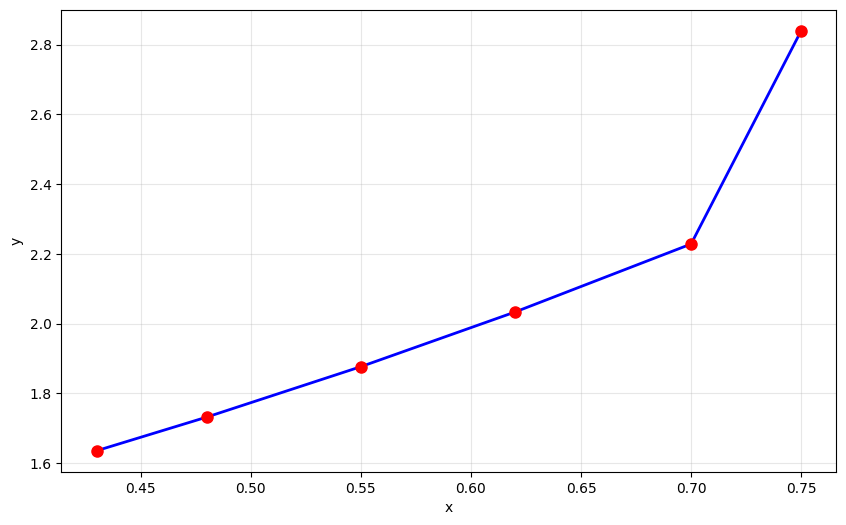

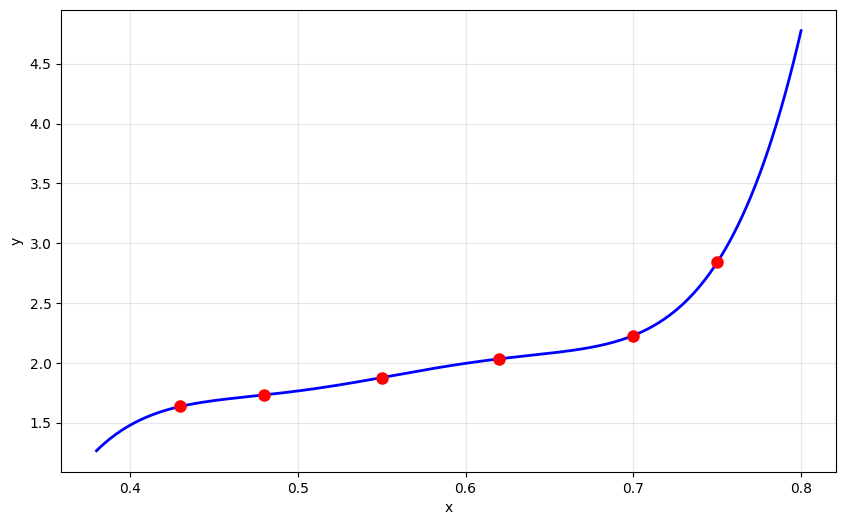

In [65]:
plot(Xk,Yk)

x_plot = np.linspace(min(Xk) - 0.05, max(Xk) + 0.05, 1000)
y_plot = [lagrange_interpolation(x_val, Xk, Yk) for x_val in x_plot]
plot(x_plot,y_plot)

### **Решение задания**

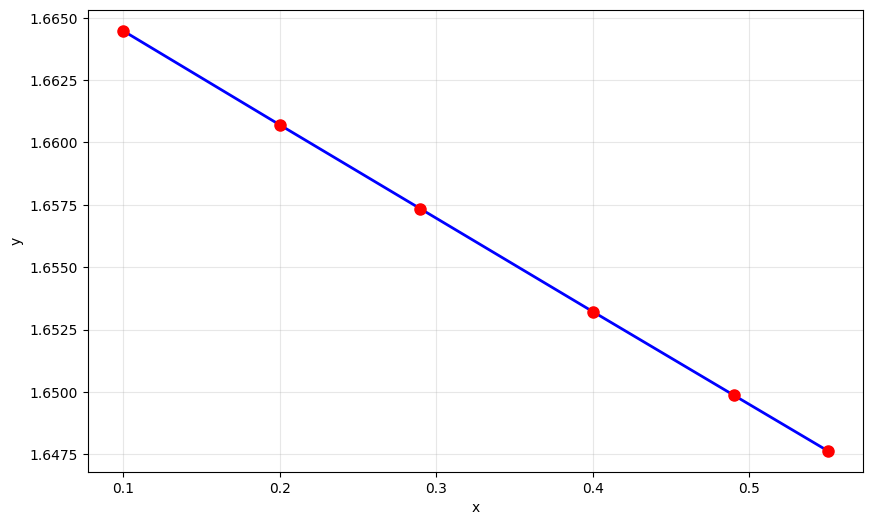

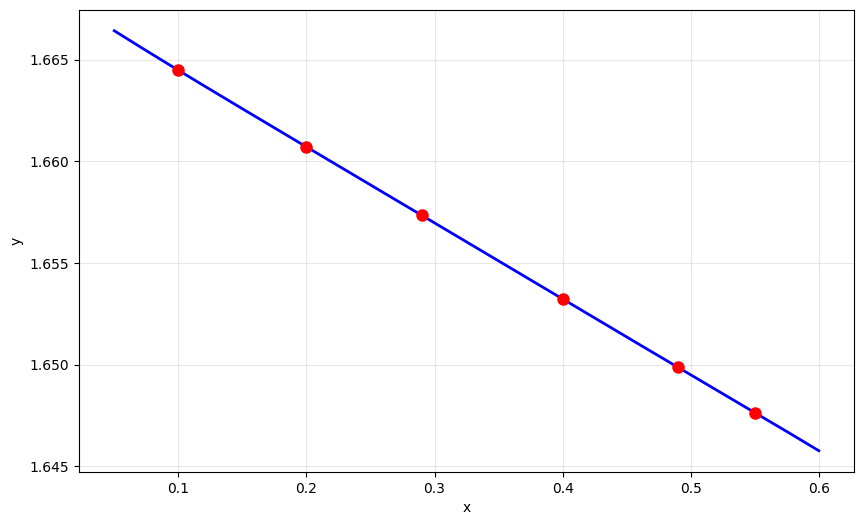


Таблица:
0.053000| -0.100000| -0.190000| -0.300000| -0.390000| -0.450000| D0 = -0.0010003500 | Y0/D0 = -1663.8976358275
0.100000| -0.047000| -0.090000| -0.200000| -0.290000| -0.350000| D1 = 0.0001827000 | Y1/D1 = 9089.8193760263
0.190000| 0.090000| -0.137000| -0.110000| -0.200000| -0.260000| D2 = -0.0000978120 | Y2/D2 = -16944.1377336114
0.300000| 0.200000| 0.110000| -0.247000| -0.090000| -0.150000| D3 = 0.0000891000 | Y3/D3 = 18554.6576879910
0.390000| 0.290000| 0.200000| 0.090000| -0.337000| -0.060000| D4 = -0.0001221480 | Y4/D4 = -13507.1388807021
0.450000| 0.350000| 0.260000| 0.150000| 0.060000| -0.397000| D5 = 0.0003685500 | Y5/D5 = 4470.6010039343

Произведение главной диагонали (D0) = -1.127747e-05

Y(x=0.153) = 1.6624723210


In [66]:
x = 0.153
Xk = [0.10, 0.20, 0.29, 0.40, 0.49, 0.55]
Yk = [1.66448, 1.66071, 1.65734, 1.65322, 1.64987, 1.64764]
plot(Xk,Yk)

Table, Di, D0, result = lagrange_tablica(x, Xk, Yk)

x_plot = np.linspace(min(Xk) - 0.05, max(Xk) + 0.05, 1000)
y_plot = [lagrange_interpolation(x_val, Xk, Yk) for x_val in x_plot]

plot(x_plot,y_plot)
print_lagrange(Table, Di, D0, Yk, result, x)


# Задание 2

По таблице с равноотстоящими значениями аргумента вычислить значения
функции для заданных значений аргументов, используя первую и вторую
интерполяционные формулы Ньютона.

Точность $e\le0.000001$

$x_1=0.455$<br>
$x_2=0.5575$<br>
$x_3=0.440$<br>
$x_4=0.5674$<br>

|$k$|$X_k$|$Y_k$|
|--|--|--|
|0|0.45|20.1946|
|1|0.46|19.6133|
|2|0.47|18.9425|
|3|0.48|18.1746|
|4|0.49|17.3010|
|5|0.50|16.3123|
|6|0.51|15.1984|
|7|0.52|13.9484|
|8|0.53|12.5508|
|9|0.54|10.9987|
|10|0.55|9.2647|
|11|0.56|7.3510|
||шаг=0.01|


## Объяснение

Интерполяционные формулы Ньютона применяют в таблицах с
постоянным шагом h=const.
<br> 1-ую формулу Ньютона используют для интерполяции в начале таблицы.
<br>2-ую формулу Ньютона используют для интерполяции в конце таблицы.
<br> В основе формул Ньютона – аппарат конечных разностей.

Первая формула:
$$
P_n(x)=y_0 + q \Delta y_0 + \frac{q(q-1)}{2!} \Delta^2y_0 +...+
\frac{q(q-1)...(q-n+1)}{n!} \Delta^n y_0
$$

В **1-ую** интерполяционную формулу Ньютона подставляют значения из
**первой строки** таблицы конечных разностей, а значение параметра q
вычисляют по формуле: q = (x-x0)/h>0.
$$
q=\frac{(x-x_0)}{h} > 0
$$
короче где начало таблицы

Вторая формула:
$$
P_n(x)=y_n + q \Delta y_{n-1} + \frac{q(q+1)}{2!} \Delta^2y_{n-2} +...+
\frac{q(q+1)...(q+n-1)}{n!} \Delta^n y_0
$$

Во **2-ую** интерполяционную формулу Ньютона подставляют значения с
**диагонали** таблицы конечных разностей, а значение параметра q
вычисляют по формуле: q = (x-xn)/h<0.
$$
q=\frac{(x-x_n)}{h} < 0
$$
короче где конец таблицы

---

Для расчёта по формулам Ньютона к исходной таблице присоединяют
справа таблицу конечных разностей.

|$k$|$X_k$|$Y_k$|$\Delta y_k$|$\Delta^2 y_k$|$\Delta^3 y_k$|
|--|--|--|--|--|--|
|0|$x_0$|$y_0$|$\Delta y_0$|$\Delta^2 y_0$|$\Delta^3 y_0$|
|1|$x_1$|$y_1$|$\Delta y_1$|$\Delta^2 y_1$|$\Delta^3 y_1$|
|2|$x_2$|$y_2$|$\Delta y_1$|$\Delta^2 y_1$|-
|3|$x_3$|$y_3$|$\Delta y_1$|-|-
|4|$x_4$|$y_4$|-|-|-

---

**Степень** интерполяционного многочлена Ньютона определяется
порядком тех конечных разностей, которые оказываются практически
постоянными в построенной таблице конечных разностей. <br>
Эти формулы используют и для экстраполяции, точность которой
невелика: <br> 1-ую формулу – для интерполяции “вперёд” и экстраполяции
“назад”; <br>2-ую формулу – для интерполяции “назад” и экстраполяции
“вперёд”.

## Код

In [67]:
def diff(y):
    n = len(y)
    raz = [y]
    while len(raz[-1]) > 1:
        diff_row = [raz[-1][i+1] - raz[-1][i] for i in range(len(raz[-1])-1)]
        raz.append(diff_row)
    return raz

def newton1(x, x0, raznosti, h, max_order, start_idx=0):
    q = (x - x0) / h
    res = raznosti[0][start_idx]
    term = 1.0
    for k in range(1, min(max_order, len(raznosti))):
        term = term * (q - (k - 1)) / k
        if k < len(raznosti) and start_idx + k < len(raznosti[k]):
            res += term * raznosti[k][start_idx]
    return res

def newton2(x, xn, raznosti, h, max_order, end_idx):
    q = (x - xn) / h
    res = raznosti[0][end_idx]
    term = 1.0
    for k in range(1, min(max_order, len(raznosti))):
        term = term * (q + (k - 1)) / k
        idx = end_idx - k
        if k < len(raznosti) and idx >= 0:
            res += term * raznosti[k][idx]
    return res

def newton_methods(x, xk, raznosti, h, max_order):
    n = len(xk)

    # Экстраполяция назад (x < x0)
    if x < xk[0]:
        # print(f"Экстраполяция назад: x={x} < {xk[0]}, 1-я формула")
        return newton1(x, xk[0], raznosti, h, max_order)

    # Экстраполяция вперед (x > xn)
    if x > xk[-1]:
        # print(f"Экстраполяция вперед: x={x} > {xk[-1]}, 2-я формула")
        return newton2(x, xk[-1], raznosti, h, max_order, end_idx=len(xk)-1)

    # Интерполяция (x внутри таблицы)

    for i in range(n - 1):
        if xk[i] <= x <= xk[i+1]:
            q = (x - xk[i]) / h
            if q <= 0.5:
                return newton1(x, xk[i], raznosti, h, max_order, start_idx=i)
            else:
                return newton2(x, xk[i+1], raznosti, h, max_order, end_idx=i+1)
    return None

## Решение задания

In [68]:
xk = [
    0.45,
    0.46,
    0.47,
    0.48,
    0.49,
    0.50,
    0.51,
    0.52,
    0.53,
    0.54,
    0.55,
    0.56
      ]
yk = [
    20.1946,
    19.6133,
    18.9425,
    18.1746,
    17.3010,
    16.3123,
    15.1984,
    13.9484,
    12.5508,
    10.9987,
    9.2647,
    7.3510,
]
h = 0.01

raznosti=diff(yk)

max_order = len(xk) - 1

x1 = 0.455
x2 = 0.5575
x3 = 0.440
x4 = 0.5674

y1 = newton_methods(x1, xk, raznosti, h, max_order)
print(f"Y({x1}) = {y1:.10f}\n")

y2 = newton_methods(x2, xk, raznosti, h, max_order)
print(f"Y({x2}) = {y2:.10f}\n")

y3 = newton_methods(x3, xk, raznosti, h, max_order)
print(f"Y({x3}) = {y3:.10f}\n")

y4 = newton_methods(x4, xk, raznosti, h, max_order)
print(f"Y({x4}) = {y4:.10f}\n")

Y(0.455) = 19.9039500000

Y(0.5575) = 7.8328023358

Y(0.44) = 20.6928000000

Y(0.5674) = 6.1967998699



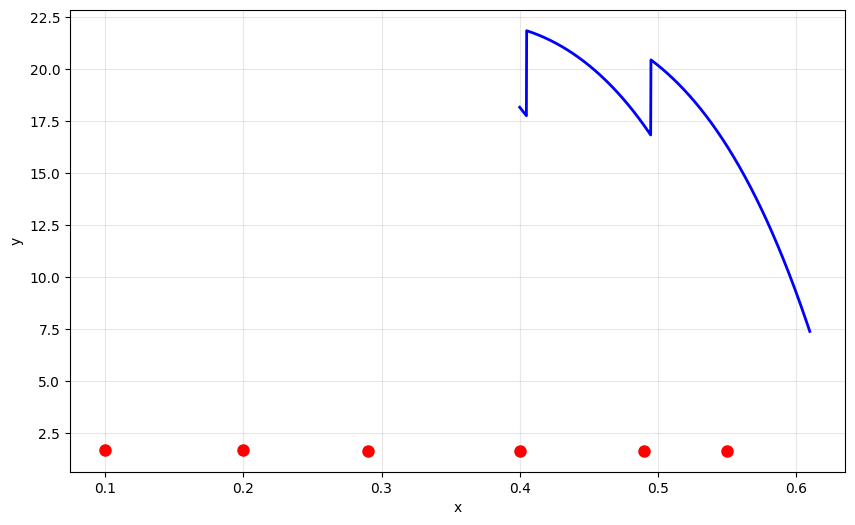


Таблица:
0.053000| -0.100000| -0.190000| -0.300000| -0.390000| -0.450000| D0 = -0.0010003500 | Y0/D0 = -1663.8976358275
0.100000| -0.047000| -0.090000| -0.200000| -0.290000| -0.350000| D1 = 0.0001827000 | Y1/D1 = 9089.8193760263
0.190000| 0.090000| -0.137000| -0.110000| -0.200000| -0.260000| D2 = -0.0000978120 | Y2/D2 = -16944.1377336114
0.300000| 0.200000| 0.110000| -0.247000| -0.090000| -0.150000| D3 = 0.0000891000 | Y3/D3 = 18554.6576879910
0.390000| 0.290000| 0.200000| 0.090000| -0.337000| -0.060000| D4 = -0.0001221480 | Y4/D4 = -13507.1388807021
0.450000| 0.350000| 0.260000| 0.150000| 0.060000| -0.397000| D5 = 0.0003685500 | Y5/D5 = 4470.6010039343

Произведение главной диагонали (D0) = -1.127747e-05

Y(x=0.153) = 1.6624723210


In [69]:
xk = [
    0.45,
    0.46,
    0.47,
    0.48,
    0.49,
    0.50,
    0.51,
    0.52,
    0.53,
    0.54,
    0.55,
    0.56
      ]
yk = [
    20.1946,
    19.6133,
    18.9425,
    18.1746,
    17.3010,
    16.3123,
    15.1984,
    13.9484,
    12.5508,
    10.9987,
    9.2647,
    7.3510,
]

x_plot = np.linspace(min(xk) - 0.05, max(xk) + 0.05, 1000)
y_plot = [newton_methods(x_val, Xk,raznosti,0.01,7) for x_val in x_plot]
plot(x_plot,y_plot)

Table, Di, D0, result = lagrange_tablica(x, Xk, Yk)
print_lagrange(Table, Di, D0, Yk, result, x)


# Задание 3

По заданным экспериментальным точкам выбрать вид эмпирической
зависимости и выполнить среднеквадратичное приближение функции,
применив метод наименьших квадратов для оценки параметров выбранной
зависимости.

|x|y|
|--|--|
|3.0|25.0|   
|3.1|29.4|   
|3.2|34.4|   
|3.3|40.4|   
|3.4|47.6|   
|3.5|56.0|

## Объяснение

По графику на глаз весьма трудно выбрать тип аналитической
зависимости. Поэтому был предложен **способ ориентировочной оценки
и выбора типа аналитической зависимости**. <br>

Предлагается следующий алгоритм действий: <br>

1. В исходной таблице выбрать две далеко отстоящие друг от друга
точки с координатами (x1,y1) и (xn,yn) - опорные точки, и для каждой
пары координат вычислить среднее арифметическое, среднее
геометрическое и среднее гармоническое.


$$x_{ар}=0.5(x_i+x_n); y_{ар}=0.5(y_1+y_n)$$
$$x_{геом}=\sqrt{x_1x_n};y_{геом}=\sqrt{y_1y_n}$$
$$x_{гарм}=\frac{2x_1x_n}{x_1+x_n};y_{гарм}=\frac{2y_1y_n}{y_1+y_n}$$


2. На кривой, проведённой через поле экспериментальных точек, найти
три ординаты, соответствующие найденным абсциссам $x_{ар}$ $x_{геом}$ $x_{гарм}$.
$$
y_1^*=y(x_{ар}) 
y_2^*(x_{геом})
y_3^*=y(x_{гарм})

$$

3. Выполнить сравнение найденных на кривой y_1^* y_2^* y_3^* с
вычисленными  $y_{ар}, y_{геом}, y_{гарм}$, путём вычисления следующих модулей разностей: <br>

$\Epsilon_1=|y_1^*-y_{ар}|$<br>
$\Epsilon_2=|y_1^*-y_{геом}|$<br>
$\Epsilon_3=|y_1^*-y_{гарм}|$<br>
$\Epsilon_4=|y_2^*-y_{ар}|$<br>
$\Epsilon_5=|y_2^*-y_{геом}|$<br>
$\Epsilon_6=|y_3^*-y_{ар}|$<br>
$\Epsilon_7=|y_3^*-y_{гарм}|$<br>


4. Из найденных значений $\Epsilon$ выбирается минимальное: $\Epsilon=\min{(\Epsilon_1,\Epsilon_2,...,\Epsilon_n)}$

5. Выводы: если минимальным оказалось

$\Epsilon_1$ - зависимость линейная: $y=ax+b$<br>
$\Epsilon_2$ - зависимость показательная: $y=ab^x$<br>
$\Epsilon_3$ - зависимость дробно-линейная: $y=\frac{1}{ax+b}$<br>
$\Epsilon_4$ - зависимость логарифмическая: $y=a\ln{x}+b$<br>
$\Epsilon_5$ - зависимость степенная: $y=ax^b$<br>
$\Epsilon_6$ - зависимость гиперболическая: $y=a+\frac{b}{x}$<br>
$\Epsilon_7$ - зависимость дробно-рациональная: $y=\frac{x}{ax+b}$<br>

Любую из этих зависимостей можно свести к линейной, выполнив
преобразование координат или так называемое **выравнивание данных**:<br>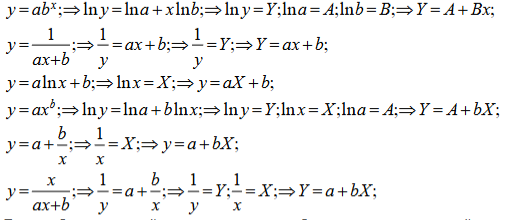

---

**Второй этап** состоит в определении наилучших значений
коэффициентов выбранной аналитической зависимости. Для этого
применяют математический **метод наименьших квадратов**.

В основе метода – минимизация суммы квадратов отклонений заданных
табличных значений $(y_i^{эксп})$ от вычисленных по теоретической
зависимости $(y_i^{теор})$: $F=\sum_{1}^n(y_i^{эксп}-y_i^{теор})^2 \rightarrow \min$

Пусть выбранная зависимость – прямая линия: $y=ax+b$. Подставим в
функционал $F: y_i^{теор}=ax+b$ Тогда минимизируется функционал:

$$
F=\sum_{1}^{n}(y_i^{э}-ax_i-b)^2 \rightarrow \min
$$

Для нахождения наилучших значений коэффициентовa иb надо найти
частные производные отF поa иb и приравнять их нулю:

$$
\frac{\Delta F}{\Delta a}=\sum_1^n(y_i-ax_i-b)x_i=0
$$
$$
\frac{\Delta F}{\Delta b}=\sum_1^n(y_i-ax_i-b)=0
$$

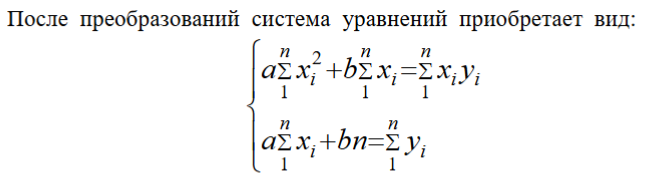

## Код

Выбрана зависимость: показательная (ε2 = 0.0166)

Уравнение: y = 0.198874·5.008055^x

   x       y(табл)      y(теор)       откл   
  3.00     25.0000      24.9797     0.020346 
  3.10     29.4000      29.3463     0.053702 
  3.20     34.4000      34.4763     0.076267 
  3.30     40.4000      40.5030     0.102995 
  3.40     47.6000      47.5832     0.016755 
  3.50     56.0000      55.9012     0.098821 

Сумма квадратов отклонений: 0.029769
Среднее квадратичное отклонение: 0.004961


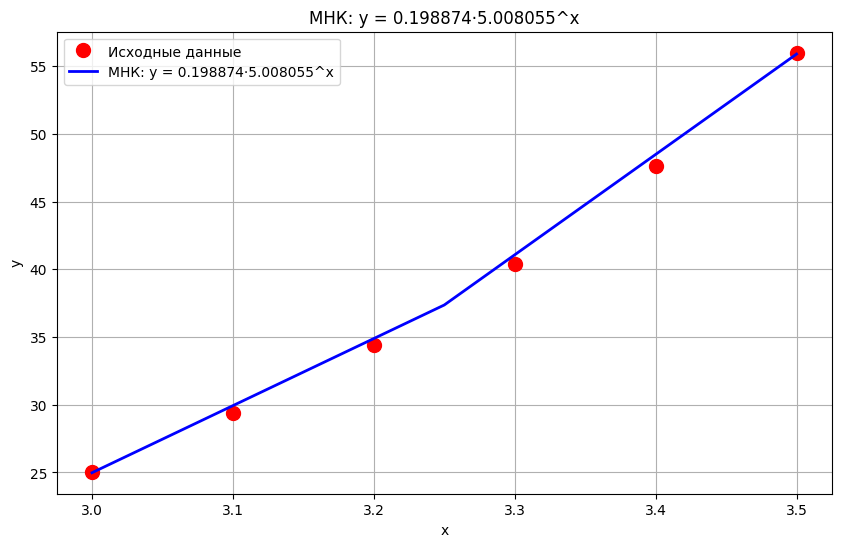

In [70]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Исходные данные
x = [3.0, 3.1, 3.2, 3.3, 3.4, 3.5]
y = [25.0, 29.4, 34.4, 40.4, 47.6, 56.0]

# Опорные точки
x1, xn = x[0], x[-1]
y1, yn = y[0], y[-1]

# Средние значения
x_ar, y_ar = 0.5*(x1 + xn), 0.5*(y1 + yn)
x_geom, y_geom = math.sqrt(x1*xn), math.sqrt(y1*yn)
x_harm, y_harm = 2*x1*xn/(x1+xn), 2*y1*yn/(y1+yn)

# Линейная интерполяция для нахождения y* на кривой
def interp(x_val):
    for i in range(len(x)-1):
        if x[i] <= x_val <= x[i+1]:
            t = (x_val - x[i]) / (x[i+1] - x[i])
            return y[i] + t*(y[i+1] - y[i])
    return None

# Значения y* на кривой
y1_star = interp(x_ar)
y2_star = interp(x_geom)
y3_star = interp(x_harm)

eps = [
    abs(y1_star - y_ar),
    abs(y1_star - y_geom),
    abs(y1_star - y_harm),
    abs(y2_star - y_ar),
    abs(y2_star - y_geom),
    abs(y3_star - y_ar),
    abs(y3_star - y_harm)
]

dep = {
    1:"линейная",
    2:"показательная",
    3:"дробно-линейная",
    4:"логарифмическая",
    5:"степенная",
    6:"гиперболическая",
    7:"дробно-рациональная"
}

choice = eps.index(min(eps)) + 1
print(f"Выбрана зависимость: {dep[choice]} (ε{choice} = {min(eps):.4f})")

def mnk(x, y, typ):
    n = len(x)
    if typ == 1:
        sx, sy = sum(x), sum(y)
        sxy = sum(x[i]*y[i] for i in range(n))
        sx2 = sum(xi**2 for xi in x)
        a = (n*sxy - sx*sy)/(n*sx2 - sx**2)
        b = (sy - a*sx)/n
        yt = [a*xi + b for xi in x]
        return f"y = {a:.6f}·x + {b:.6f}", yt, a, b

    elif typ == 2:
        Y = [math.log(yi) for yi in y]
        sx, sY = sum(x), sum(Y)
        sxY = sum(x[i]*Y[i] for i in range(n))
        sx2 = sum(xi**2 for xi in x)
        B = (n*sxY - sx*sY)/(n*sx2 - sx**2)
        A = (sY - B*sx)/n
        a, b = math.exp(A), math.exp(B)
        yt = [a*(b**xi) for xi in x]
        return f"y = {a:.6f}·{b:.6f}^x", yt, a, b

    elif typ == 3:
        Y = [1/yi for yi in y]
        sx, sY = sum(x), sum(Y)
        sxy = sum(x[i]*Y[i] for i in range(n))
        sx2 = sum(xi**2 for xi in x)
        a = (n*sxy - sx*sY)/(n*sx2 - sx**2)
        b = (sY - a*sx)/n
        yt = [1/(a*xi + b) for xi in x]
        return f"y = 1/({a:.6f}·x + {b:.6f})", yt, a, b

    elif typ == 4:
        X = [math.log(xi) for xi in x]
        sx, sY = sum(X), sum(y)
        sxy = sum(X[i]*y[i] for i in range(n))
        sx2 = sum(xi**2 for xi in X)
        a = (n*sxy - sx*sY)/(n*sx2 - sx**2)
        b = (sY - a*sx)/n
        yt = [a*math.log(xi) + b for xi in x]
        return f"y = {a:.6f}·ln(x) + {b:.6f}", yt, a, b

    elif typ == 5:
        X = [math.log(xi) for xi in x]
        Y = [math.log(yi) for yi in y]
        sx, sY = sum(X), sum(Y)
        sxy = sum(X[i]*Y[i] for i in range(n))
        sx2 = sum(xi**2 for xi in X)
        b = (n*sxy - sx*sY)/(n*sx2 - sx**2)
        a = math.exp((sum(Y) - b*sx)/n)
        yt = [a*(xi**b) for xi in x]
        return f"y = {a:.6f}·x^{b:.6f}", yt, a, b

    elif typ == 6:
        X = [1/xi for xi in x]
        sx, sY = sum(X), sum(y)
        sxy = sum(X[i]*y[i] for i in range(n))
        sx2 = sum(xi**2 for xi in X)
        b = (n*sxy - sx*sY)/(n*sx2 - sx**2)
        a = (sum(y) - b*sx)/n
        yt = [a + b/xi for xi in x]
        return f"y = {a:.6f} + {b:.6f}/x", yt, a, b

    elif typ == 7:
        XY = [xi/yi for xi, yi in zip(x, y)]
        sx, sY = sum(x), sum(XY)
        sxy = sum(x[i]*XY[i] for i in range(n))
        sx2 = sum(xi**2 for xi in x)
        a = (n*sxy - sx*sY)/(n*sx2 - sx**2)
        b = (sY - a*sx)/n
        yt = [xi/(a*xi + b) for xi in x]
        return f"y = x/({a:.6f}·x + {b:.6f})", yt, a, b

formula, yt, a, b = mnk(x, y, choice)

print(f"\nУравнение: {formula}")
print(f"\n{'x':^8} {'y(табл)':^12} {'y(теор)':^12} {'откл':^10}")
for xi, yi, yti in zip(x, y, yt):
    print(f"{xi:^8.2f} {yi:^12.4f} {yti:^12.4f} {abs(yi - yti):^10.6f}")

ss = sum((y[i]-yt[i])**2 for i in range(len(x)))
print(f"\nСумма квадратов отклонений: {ss:.6f}")
print(f"Среднее квадратичное отклонение: {ss/len(x):.6f}")

# ============= ГРАФИК =============
x_plot = np.linspace(3.0, 3.5, 3)

# Считаем y для плавной кривой по той же формуле
if choice == 1:
    y_plot = a * x_plot + b
elif choice == 2:
    y_plot = a * (b ** x_plot)
elif choice == 3:
    y_plot = 1 / (a * x_plot + b)
elif choice == 4:
    y_plot = a * np.log(x_plot) + b
elif choice == 5:
    y_plot = a * (x_plot ** b)
elif choice == 6:
    y_plot = a + b / x_plot
elif choice == 7:
    y_plot = x_plot / (a * x_plot + b)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', markersize=10, label='Исходные данные')
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label=f'МНК: {formula}')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'МНК: {formula}')
plt.grid(True)
plt.legend()
plt.show()

---

# Cравнение методов лагранжа и ньютона

## Из задания 1

In [71]:
# из задания 1
Xk1 = [0.10, 0.20, 0.29, 0.40, 0.49, 0.55]
Yk1 = [1.66448, 1.66071, 1.65734, 1.65322, 1.64987, 1.64764]
x_target1 = 0.153

# Решение методом Лагранжа
_, _, _, result_lagrange1 = lagrange_tablica(x_target1, Xk1, Yk1)

# Решение методом Ньютона
def newton_interpolation_unequal(x, Xk, Yk):
    n = len(Xk)
    # таблица для разностей
    div_diff = [[0.0] * (n - i) for i in range(n)]
    for i in range(n):
        div_diff[0][i] = Yk[i]
    # таблица для разностей


    # вычисление разностей
    for j in range(1, n):
        for i in range(n - j):
            div_diff[j][i] = (div_diff[j-1][i+1] - div_diff[j-1][i]) / (Xk[i+j] - Xk[i])
    #  вычисление разностей

    # вычисление интерполяционного многочлена Ньютона
    result = div_diff[0][0]
    term = 1.0
    for j in range(1, n):
        term *= (x - Xk[j-1])
        result += div_diff[j][0] * term
    # вычисление интерполяционного многочлена Ньютона
    return result

result_newton1 = newton_interpolation_unequal(x_target1, Xk1, Yk1)

print(f"\nДля x = {x_target1}:\n"
      f"Метод Лагранжа:  y = {result_lagrange1:.10f}\n"
      f"Метод Ньютона:   y = {result_newton1:.10f}")




Для x = 0.153:
Метод Лагранжа:  y = 1.6624723210
Метод Ньютона:   y = 1.6624723210


## Графики 1

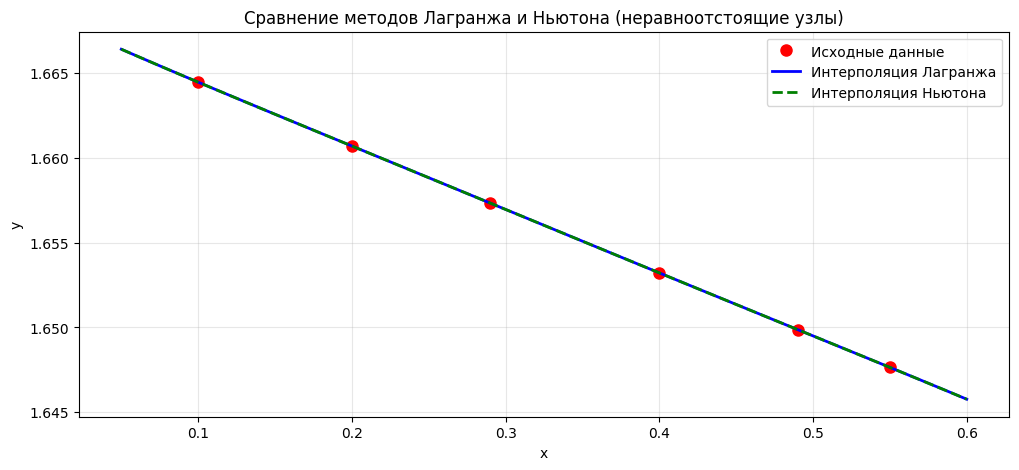

In [72]:

# график
fig1, ax1 = plt.subplots(figsize=(12, 5))

# точки
ax1.plot(Xk1, Yk1, 'ro', markersize=8, label='Исходные данные')

# графики интерполяции Лагранжа и Ньютона
x_plot1 = np.linspace(min(Xk1) - 0.05, max(Xk1) + 0.05, 100)
y_lagrange_plot1 = [lagrange_interpolation(x_val, Xk1, Yk1) for x_val in x_plot1]
y_newton_plot1 = [newton_interpolation_unequal(x_val, Xk1, Yk1) for x_val in x_plot1]

ax1.plot(x_plot1, y_lagrange_plot1, 'b-', linewidth=2, label='Интерполяция Лагранжа')
ax1.plot(x_plot1, y_newton_plot1, 'g--', linewidth=2, label='Интерполяция Ньютона')

ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Сравнение методов Лагранжа и Ньютона (неравноотстоящие узлы)')
ax1.grid(True, alpha=0.3)
ax1.legend()
plt.show()


## Из задания 2

In [73]:

# задание 2
Xk2 = [0.45, 0.46, 0.47, 0.48, 0.49, 0.50, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56]
Yk2 = [20.1946, 19.6133, 18.9425, 18.1746, 17.3010, 16.3123, 15.1984,
       13.9484, 12.5508, 10.9987, 9.2647, 7.3510]
h2 = 0.01

# Вычисляем конечные разности для метода Ньютона
raznosti2 = diff(Yk2)
max_order2 = len(Xk2) - 1

# Точки для интерполяции
x_targets2 = [0.455, 0.5575, 0.440, 0.5674]

print("\nСравнение результатов:")
print("-" * 60)
print(f"{'x':^12} | {'Ньютон':^18} | {'Лагранж':^18}")
print("-" * 60)


for x_val in x_targets2:
    y_newton = newton_methods(x_val, Xk2, raznosti2, h2, max_order2)
    _, _, _, y_lagrange = lagrange_tablica(x_val, Xk2, Yk2)



    print(f"{x_val:^12.4f} {y_newton:^18.10f} {y_lagrange:^18.10f}")


Сравнение результатов:
------------------------------------------------------------
     x       |       Ньютон       |      Лагранж      
------------------------------------------------------------
   0.4550      19.9039500000      19.9173670097   
   0.5575       7.8328023358       7.8299834886   
   0.4400      20.6928000000      20.3692000000   
   0.5674       6.1967998699       6.3138191826   


## Графики 2

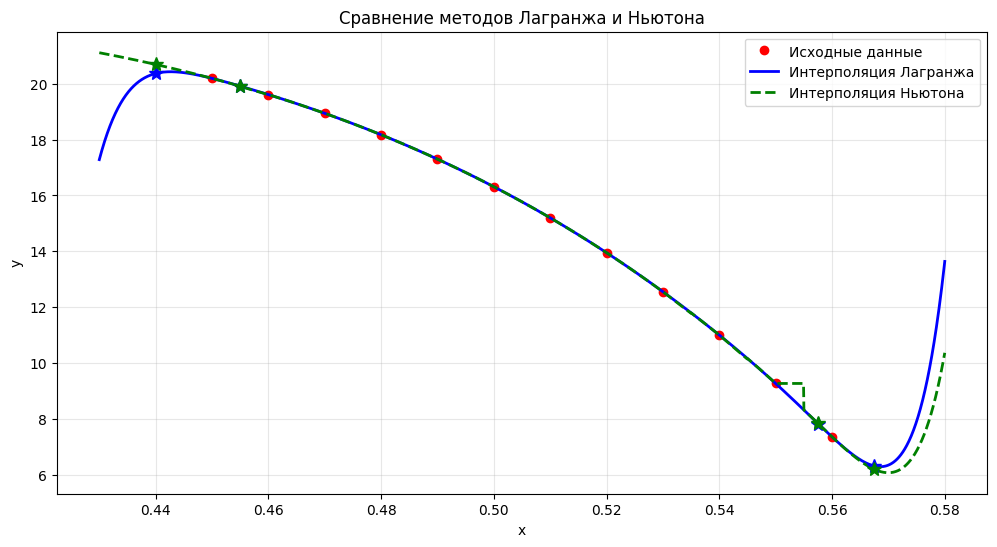

In [74]:

# График
fig2, ax2 = plt.subplots(figsize=(12, 6))

# Исходные точки
ax2.plot(Xk2, Yk2, 'ro', markersize=6, label='Исходные данные')

# построение графиков интерполяции
x_plot2 = np.linspace(min(Xk2) - 0.02, max(Xk2) + 0.02, 2222)
y_lagrange_plot2 = [lagrange_interpolation(x_val, Xk2, Yk2) for x_val in x_plot2]
y_newton_plot2 = [newton_methods(x_val, Xk2, raznosti2, h2, max_order2) for x_val in x_plot2]

ax2.plot(x_plot2, y_lagrange_plot2, 'b-', linewidth=2, label='Интерполяция Лагранжа')
ax2.plot(x_plot2, y_newton_plot2, 'g--', linewidth=2, label='Интерполяция Ньютона')
# построение графиков интерполяции

# интерполируемые точки
for x_val in x_targets2:
    y_lag = lagrange_interpolation(x_val, Xk2, Yk2)
    y_new = newton_methods(x_val, Xk2, raznosti2, h2, max_order2)
    ax2.plot(x_val, y_lag, 'b*', markersize=10)
    ax2.plot(x_val, y_new, 'g*', markersize=10)
# интерполируемые точки
plt.title('Сравнение методов Лагранжа и Ньютона')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.show()


---


Проверка: ваши коэффициенты vs функция Ньютона из кода

Коэффициенты из ВАШЕГО кода (функция Ньютона):
  a0 = 20.1946000000
  a1 = -58.1300000000
  a2 = -447.5000000000
  a3 = -1266.6666666654
  a4 = -4166.6666667472

Ваши коэффициенты (найденные вручную):
  a0 = 20.1946
  a1 = -58.1300
  a2 = -447.5000
  a3 = -1266.6600
  a4 = -4167.3300


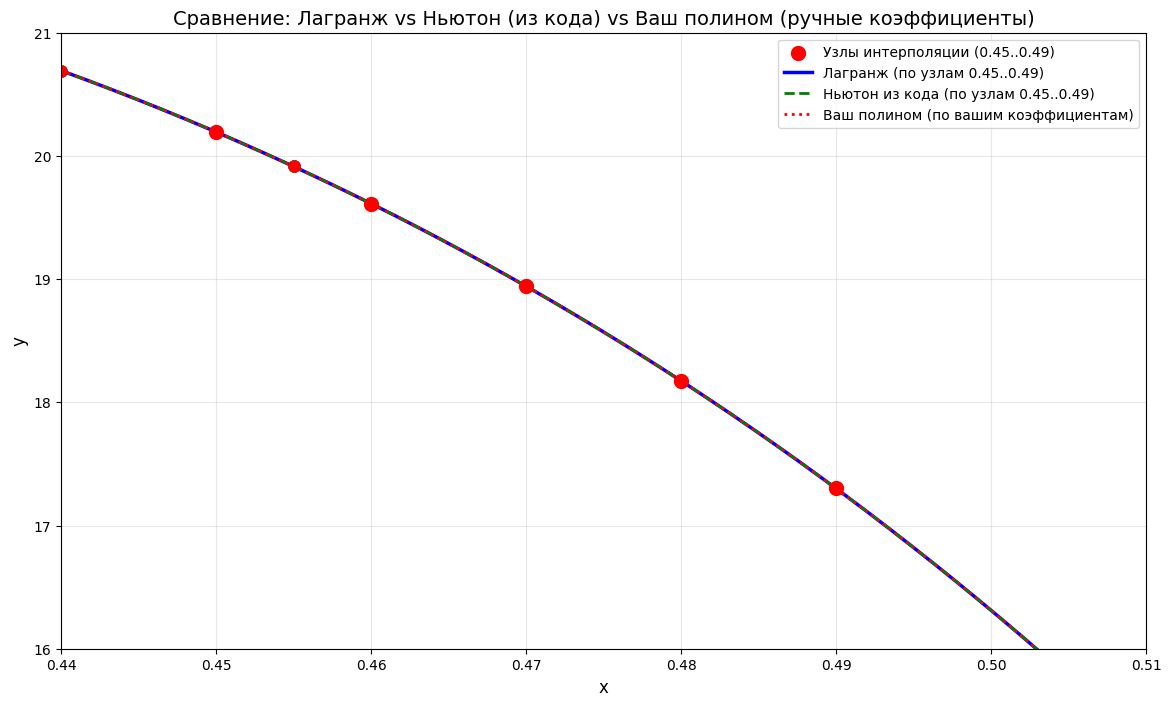


ВЫВОД:
Если зелёная (Ньютон) и синяя (Лагранж) линии совпадают —
значит функции в коде работают правильно.

Если красная пунктирная линия (ваши коэффициенты) НЕ совпадает
с синей/зелёной — значит вы НЕПРАВИЛЬНО нашли коэффициенты.


In [75]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ВАШИ ФУНКЦИИ ИЗ КОДА (скопированы для работы здесь)
# ============================================================

def lagrange_interpolation(x_val, Xk, Yk):
    """Интерполяция Лагранжа"""
    n = len(Xk)
    result = 0.0
    for i in range(n):
        term = Yk[i]
        for j in range(n):
            if j != i:
                term *= (x_val - Xk[j]) / (Xk[i] - Xk[j])
        result += term
    return result

def newton_interpolation_unequal(x, Xk, Yk):
    """Интерполяция Ньютона для неравноотстоящих узлов (из вашего кода)"""
    n = len(Xk)
    # таблица разделённых разностей
    div_diff = [[0.0] * (n - i) for i in range(n)]
    for i in range(n):
        div_diff[0][i] = Yk[i]

    for j in range(1, n):
        for i in range(n - j):
            div_diff[j][i] = (div_diff[j-1][i+1] - div_diff[j-1][i]) / (Xk[i+j] - Xk[i])

    # вычисление полинома
    result = div_diff[0][0]
    term = 1.0
    for j in range(1, n):
        term *= (x - Xk[j-1])
        result += div_diff[j][0] * term
    return result

# ============================================================
# ДАННЫЕ (из задания 2)
# ============================================================
# Полные данные (12 точек)
Xk_full = np.array([0.45, 0.46, 0.47, 0.48, 0.49, 0.50, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56])
Yk_full = np.array([20.1946, 19.6133, 18.9425, 18.1746, 17.3010, 16.3123, 15.1984,
                    13.9484, 12.5508, 10.9987, 9.2647, 7.3510])

# ============================================================
# ВАШИ КОЭФФИЦИЕНТЫ (степень 4, т.е. 5 узлов)
# ============================================================
# Узлы, по которым вы считали (первые 5 точек из таблицы)
Xk_your = Xk_full[:5]  # [0.45, 0.46, 0.47, 0.48, 0.49]
Yk_your = Yk_full[:5]  # [20.1946, 19.6133, 18.9425, 18.1746, 17.3010]

# Ваши коэффициенты (которые вы нашли руками)
a_your = np.array([20.1946, -58.13, -447.5, -1266.66, -4167.33])

# ============================================================
# НО! ВАШИ КОЭФФИЦИЕНТЫ НЕ СООТВЕТСТВУЮТ ВАШИМ ЖЕ УЗЛАМ
# Проверим: что выдаст функция Ньютона для узлов Xk_your?
# ============================================================

print("=" * 70)
print("Проверка: ваши коэффициенты vs функция Ньютона из кода")
print("=" * 70)

# Коэффициенты, вычисленные функцией Ньютона (должны совпадать с вашими, если вы правильно нашли)
def get_newton_coeffs(Xk, Yk):
    n = len(Xk)
    div_diff = [[0.0] * (n - i) for i in range(n)]
    for i in range(n):
        div_diff[0][i] = Yk[i]
    for j in range(1, n):
        for i in range(n - j):
            div_diff[j][i] = (div_diff[j-1][i+1] - div_diff[j-1][i]) / (Xk[i+j] - Xk[i])
    return [div_diff[j][0] for j in range(n)]

coeffs_from_code = get_newton_coeffs(Xk_your, Yk_your)

print("\nКоэффициенты из ВАШЕГО кода (функция Ньютона):")
for i, c in enumerate(coeffs_from_code):
    print(f"  a{i} = {c:.10f}")

print("\nВаши коэффициенты (найденные вручную):")
for i, c in enumerate(a_your):
    print(f"  a{i} = {c:.4f}")


# ============================================================
# ПОСТРОЕНИЕ ГРАФИКОВ
# ============================================================

x_plot = np.linspace(0.44, 0.52, 500)  # Область вблизи узлов

# 1. Ваш полином (через функцию Лагранжа по узлам Xk_your)
y_lagrange_your = np.array([lagrange_interpolation(xv, Xk_your, Yk_your) for xv in x_plot])

# 2. Ваш полином (через функцию Ньютона из кода)
y_newton_your = np.array([newton_interpolation_unequal(xv, Xk_your, Yk_your) for xv in x_plot])

# 3. Полином, построенный по ВАШИМ коэффициентам (ручная формула)
def newton_poly_from_coeffs(xx, x_nodes, coeffs):
    result = np.zeros_like(xx)
    for i in range(len(coeffs)):
        term = coeffs[i] * np.ones_like(xx)
        for j in range(i):
            term *= (xx - x_nodes[j])
        result += term
    return result

y_your_coeffs = newton_poly_from_coeffs(x_plot, Xk_your, a_your)

# ============================================================
# ГРАФИК
# ============================================================
plt.figure(figsize=(14, 8))

# Исходные точки (первые 5)
plt.scatter(Xk_your, Yk_your, color='red', s=100, zorder=5,
            label='Узлы интерполяции (0.45..0.49)')

# Лагранж (по тем же узлам)
plt.plot(x_plot, y_lagrange_your, 'b-', linewidth=2.5,
         label='Лагранж (по узлам 0.45..0.49)')

# Ньютон из кода
plt.plot(x_plot, y_newton_your, 'g--', linewidth=2,
         label='Ньютон из кода (по узлам 0.45..0.49)')

# Ваш полином по вашим коэффициентам
plt.plot(x_plot, y_your_coeffs, 'r:', linewidth=2,
         label='Ваш полином (по вашим коэффициентам)')

# Точки сравнения из задания
x_targets = [0.455, 0.440]
for xv in x_targets:
    y_lag = lagrange_interpolation(xv, Xk_your, Yk_your)
    y_new = newton_interpolation_unequal(xv, Xk_your, Yk_your)
    y_your = newton_poly_from_coeffs(np.array([xv]), Xk_your, a_your)[0]
    plt.plot(xv, y_lag, 'bo', markersize=8)
    plt.plot(xv, y_new, 'go', markersize=8)
    plt.plot(xv, y_your, 'ro', markersize=8)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Сравнение: Лагранж vs Ньютон (из кода) vs Ваш полином (ручные коэффициенты)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.xlim(0.44, 0.51)
plt.ylim(16, 21)
plt.show()

# ============================================================
# ВЫВОД
# ============================================================
print("\n" + "=" * 70)
print("ВЫВОД:")
print("=" * 70)
print("Если зелёная (Ньютон) и синяя (Лагранж) линии совпадают —")
print("значит функции в коде работают правильно.")
print("\nЕсли красная пунктирная линия (ваши коэффициенты) НЕ совпадает")
print("с синей/зелёной — значит вы НЕПРАВИЛЬНО нашли коэффициенты.")
print("=" * 70)